<a href="https://www.kaggle.com/code/mufidpanhalkar/customer-churn-analysis-feature-engineering?scriptVersionId=313379961" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

## 📌 Executive Summary

Customer churn directly impacts revenue and growth. This analysis explores behavioral and contractual patterns that drive churn and prepares a high-quality dataset for downstream machine learning.

Key outcomes:
- Identification of high-risk customer segments
- Creation of predictive features
- Preparation of a clean, model-ready dataset

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


# 📥 1. Import & Configuration

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

# 📂 2. Data Ingestion
👉 Use Kaggle Telco Churn dataset

In [4]:
DATA_PATH = "/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 🔍 3. Data Audit

In [5]:
print("🔍 Data Types:")
display(df.dtypes)

🔍 Data Types:


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [6]:
print("\n📊 Missing Values:")
display(df.isnull().sum())


📊 Missing Values:


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
print("\n📊 Duplicate Rows:", df.duplicated().sum())


📊 Duplicate Rows: 0


# 🧹 4. Data Cleaning

In [8]:
# Convert TotalCharges safely
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Drop missing
df = df.dropna().copy()

# Drop ID column
df.drop(columns=["customerID"], inplace=True)

print("Post-cleaning shape:", df.shape)
df.head()

Post-cleaning shape: (7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 📊 5. Target Variable Analysis

Churn
No     5163
Yes    1869
Name: count, dtype: int64


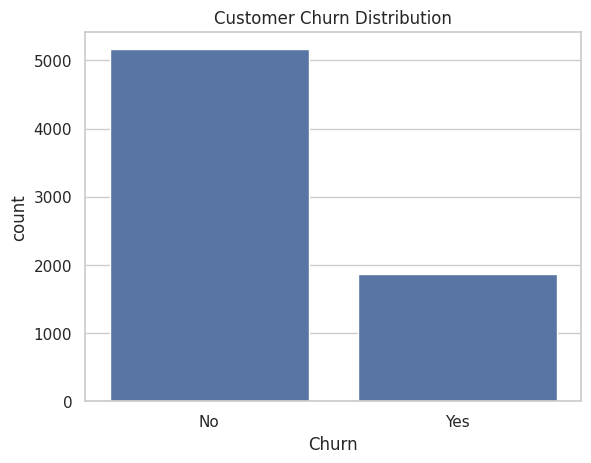

In [9]:
churn_counts = df["Churn"].value_counts()

print(churn_counts)

sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()

### Insight
- Evaluate class imbalance before modeling  
- Important for selecting evaluation metrics later  

# 📊 6. Univariate Analysis

In [10]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

df[num_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


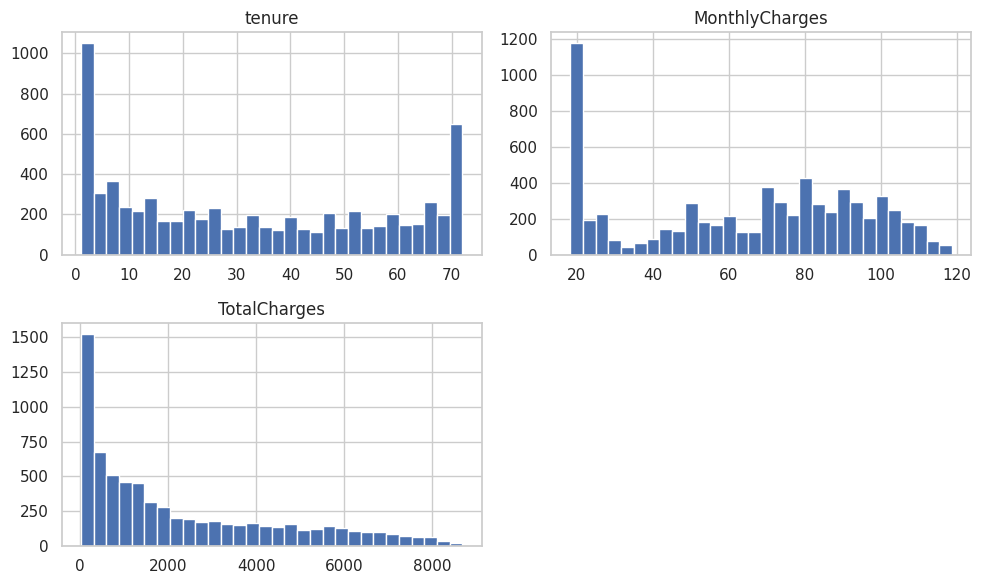

In [11]:
df[num_cols].hist(bins=30, figsize=(10,6))
plt.tight_layout()
plt.show()

# 📊 7. Categorical Feature Analysis

In [12]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    print(f"\n🔹 {col}")
    display(df[col].value_counts())


🔹 gender


gender
Male      3549
Female    3483
Name: count, dtype: int64


🔹 Partner


Partner
No     3639
Yes    3393
Name: count, dtype: int64


🔹 Dependents


...

PaperlessBilling
Yes    4168
No     2864
Name: count, dtype: int64


🔹 PaymentMethod


PaymentMethod
Electronic check             2365
Mailed check                 1604
Bank transfer (automatic)    1542
Credit card (automatic)      1521
Name: count, dtype: int64


🔹 Churn


Churn
No     5163
Yes    1869
Name: count, dtype: int64

# 📊 8. Churn Drivers (Bivariate Analysis)

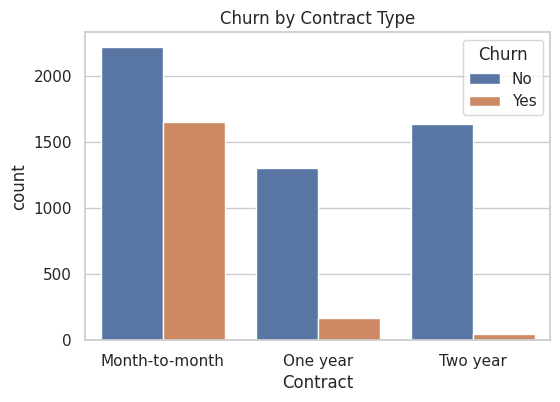

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Churn by Contract Type")
plt.show()

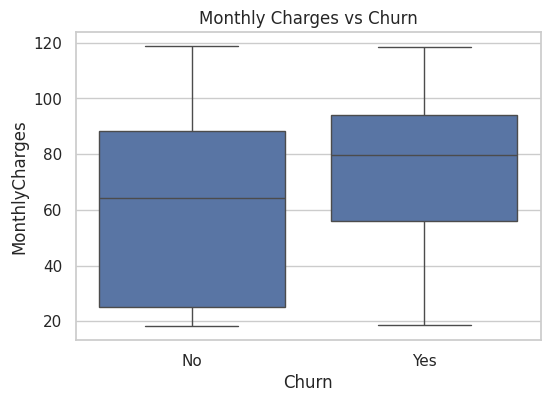

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

### Key Observations
- Month-to-month contracts show higher churn  
- Higher monthly charges correlate with churn  

# ⚙️ 9. Feature Engineering

In [15]:
# Tenure segmentation
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0,12,24,48,60,100],
    labels=["0-1yr","1-2yr","2-4yr","4-5yr","5+yr"]
)

# Spending behavior
df["AvgMonthlySpend"] = df["TotalCharges"] / (df["tenure"] + 1)

# Customer loyalty flag
df["IsLongTerm"] = (df["tenure"] > 24).astype(int)

# High value customer
df["HighValueCustomer"] = (df["MonthlyCharges"] > df["MonthlyCharges"].median()).astype(int)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,AvgMonthlySpend,IsLongTerm,HighValueCustomer
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-1yr,14.925000,0,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,2-4yr,53.985714,1,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-1yr,36.050000,0,0
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,2-4yr,40.016304,1,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-1yr,50.550000,0,1


# 🔢 10. Encoding (Minimal for next step)

In [16]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print(df["Churn"].value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


# 📊 11. Correlation Analysis

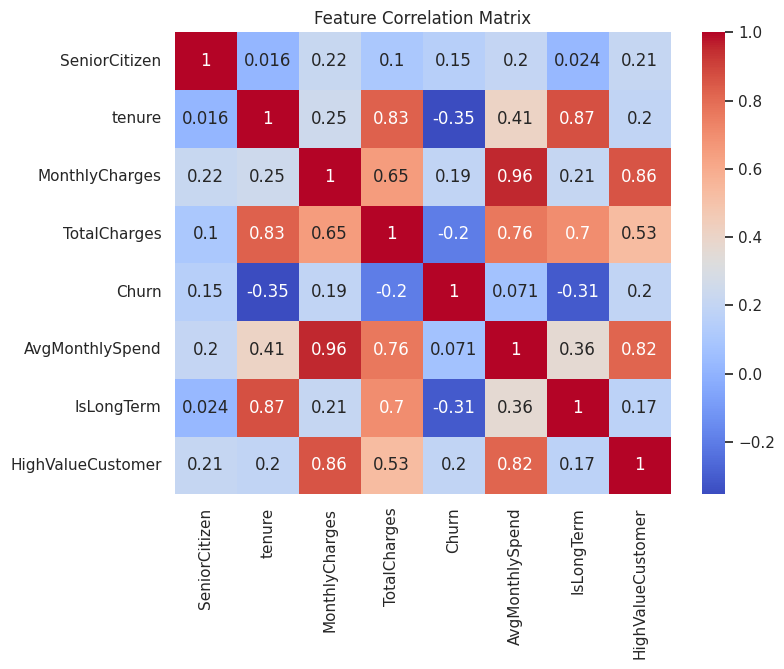

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

# 💾 12. Save Processed Data 

In [18]:
OUTPUT_PATH = Path("processed_churn.csv")

df.to_csv(OUTPUT_PATH, index=False)

print(f"✅ Processed dataset saved at: {OUTPUT_PATH}")

✅ Processed dataset saved at: processed_churn.csv


## 🧠 Key Insights

- Customers with shorter tenure are more likely to churn  
- Month-to-month contracts show higher churn rates  
- Higher monthly charges correlate with increased churn  
- Long-term customers are more stable  

---

## 🏁 Conclusion

In this notebook, we explored customer churn data and created meaningful features to better understand customer behavior.

The processed dataset is now ready for machine learning modeling in the next step.

---